In [15]:
# ================================================================
# PHASE 7 : ÉVALUATION DE SARIMA PAR SEGMENT
# Cellule 1 : Imports
# ================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from scipy.stats import kruskal
from scipy.stats import f_oneway

from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima

import joblib

plt.style.use("seaborn-v0_8-whitegrid")

sns.set_palette("Set2")

np.random.seed(42)

In [19]:
# ================================================================
# Cellule 2 : Chargement des datasets
# ================================================================

print("\nChargement des datasets...\n")

df_segments = {

    "Stable": pd.read_csv("../data/propre/dataset_segment_Stable.csv"),

    "Modere": pd.read_csv("../data/propre/dataset_segment_Modere.csv"),

    "Erratique": pd.read_csv("../data/propre/dataset_segment_Erratique.csv")

}

segments_ordered = [

    "Stable",

    "Modere",

    "Erratique"

]

for seg in segments_ordered:

    df = df_segments[seg]

    print(f"{seg:10s}")

    print(f"   lignes      : {len(df):,}")

    print(f"   stations    : {df['Code Station'].nunique()}")

    print(f"   produits    : {df['N° article'].nunique()}")

    print(f"   période     : {df['mois'].min()} → {df['mois'].max()}")

    print()


Chargement des datasets...

Stable    
   lignes      : 1,879
   stations    : 42
   produits    : 2
   période     : 2021-01-01 → 2025-12-01

Modere    
   lignes      : 2,475
   stations    : 48
   produits    : 2
   période     : 2021-01-01 → 2025-12-01

Erratique 
   lignes      : 984
   stations    : 21
   produits    : 2
   période     : 2021-01-01 → 2025-12-01



# Préparation de l'expérimentation

In [24]:

# Création des dossiers


os.makedirs("modeles_sarima", exist_ok=True)

os.makedirs("predictions_sarima", exist_ok=True)

os.makedirs("resultats_sarima", exist_ok=True)

os.makedirs("figures_sarima", exist_ok=True)

print("Dossiers créés.")

# Résultats détaillés


resultats_globaux = []

resume_segments = []

# Fonction métriques


def calculer_metriques(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, mape, r2


# Fonction affichage résumé


def afficher_resume(df):

    print()

    print(df.describe().T)

    print()


# Fonction sauvegarde CSV


def sauvegarder_dataframe(df, nom):

    chemin = f"resultats_sarima/{nom}"

    df.to_csv(
        chemin,
        index=False
    )

    print(f"✅ {nom} sauvegardé")


Dossiers créés.


# Fonction d'évaluation SARIMA sur un segment

In [75]:
def evaluation_segment_sarima(
    df_segment,
    nom_segment,
    train_ratio=0.8,
    saison=12,
    min_obs=24,
    verbose=True
):

    from pmdarima import auto_arima
    from sklearn.metrics import (
        mean_absolute_error,
        mean_squared_error,
        mean_absolute_percentage_error,
        r2_score
    )

    print("\n" + "="*70)
    print("SEGMENT :", nom_segment)
    print("="*70)

    couples = (
        df_segment[
            ["Code Station","N° article"]
        ]
        .drop_duplicates()
        .values
    )

    print("Nombre de couples :", len(couples))

    predictions = []

    mae_list=[]
    rmse_list=[]
    mape_list=[]
    r2_list=[]

    nb_ok=0
    nb_ignore=0

    for station, produit in couples:

        serie = (
            df_segment[
                (df_segment["Code Station"]==station)
                &
                (df_segment["N° article"]==produit)
            ]
            .sort_values("mois")
            .reset_index(drop=True)
        )

        if len(serie) < min_obs:
            nb_ignore += 1
            continue

        y = serie["quantite_mois"].astype(float).values

        split = int(len(y)*train_ratio)

        train = y[:split]
        test  = y[split:]

        if len(test)==0:
            nb_ignore += 1
            continue

        try:

            modele = auto_arima(

                train,

                seasonal=True,
                m=saison,

                start_p=0,
                start_q=0,
                start_P=0,
                start_Q=0,

                max_p=3,
                max_q=3,
                max_P=2,
                max_Q=2,

                max_d=2,
                max_D=1,

                stepwise=True,

                suppress_warnings=True,
                error_action="ignore",
                trace=False

            )

            prediction = modele.predict(n_periods=len(test))

        except Exception:

            # modèle de secours : moyenne historique
            prediction = np.repeat(train.mean(), len(test))

        mae = mean_absolute_error(test,prediction)
        rmse = np.sqrt(mean_squared_error(test,prediction))
        mape = mean_absolute_percentage_error(test,prediction)*100

        try:
            r2 = r2_score(test,prediction)
        except:
            r2 = np.nan

        mae_list.append(mae)
        rmse_list.append(rmse)
        mape_list.append(mape)
        r2_list.append(r2)

        nb_ok += 1

        for i in range(len(test)):

            predictions.append({

                "Segment":nom_segment,
                "Code Station":station,
                "N° article":produit,
                "Date":serie.loc[split+i,"mois"],
                "Reel":test[i],
                "Prediction":prediction[i]

            })

    predictions = pd.DataFrame(predictions)

    resultat = {

        "Segment":nom_segment,
        "Nb_couples":nb_ok,

        "MAE":np.mean(mae_list),
        "RMSE":np.mean(rmse_list),
        "MAPE":np.mean(mape_list),
        "R2":np.nanmean(r2_list)

    }

    print()
    print("Couples modélisés :", nb_ok)
    print("Couples ignorés   :", nb_ignore)
    print()

    print("MAE  :", round(resultat["MAE"],2))
    print("RMSE :", round(resultat["RMSE"],2))
    print("MAPE :", round(resultat["MAPE"],2))
    print("R²   :", round(resultat["R2"],4))

    return resultat, predictions

# Evaluation SARIMA sur tous les segments

In [77]:
resultats_sarima = {}
predictions_sarima = {}

for segment in segments_ordered:

    resultat, prediction = evaluation_segment_sarima(

        df_segments[segment],
        segment

    )

    resultats_sarima[segment] = resultat
    predictions_sarima[segment] = prediction


SEGMENT : Stable
Nombre de couples : 59

Couples modélisés : 36
Couples ignorés   : 23

MAE  : 11425.53
RMSE : 13457.35
MAPE : 32.98
R²   : -2.9449

SEGMENT : Modere
Nombre de couples : 63

Couples modélisés : 48
Couples ignorés   : 15

MAE  : 11051.03
RMSE : 12681.99
MAPE : 70.02
R²   : -3.6246

SEGMENT : Erratique
Nombre de couples : 25

Couples modélisés : 22
Couples ignorés   : 3

MAE  : 11826.48
RMSE : 12959.5
MAPE : 134.66
R²   : -9.0528


# Fusion des résultats

In [81]:
df_resultats_sarima = pd.DataFrame(

    list(resultats_sarima.values())

)

df_resultats_sarima

,Segment,Nb_couples,MAE,RMSE,MAPE,R2
0,Stable,36,11425.529754,13457.353277,32.983040,-2.944902
1,Modere,48,11051.033920,12681.992284,70.020731,-3.624634
2,Erratique,22,11826.484034,12959.497914,134.661611,-9.052815


# Performances moyennes par segment

In [87]:
predictions_totales = pd.concat(

    predictions_sarima.values(),

    ignore_index=True

)

predictions_totales.to_csv(

    "predictions_sarima_segments.csv",

    index=False

)

print(predictions_totales.head(40))

   Segment Code Station N° article        Date      Reel     Prediction
0   Stable       ST0001      A0001  2025-07-01  107000.0   88666.666667
1   Stable       ST0001      A0001  2025-08-01   42000.0   88666.666667
2   Stable       ST0001      A0001  2025-09-01  109000.0   88666.666667
3   Stable       ST0001      A0001  2025-10-01  100000.0   88666.666667
4   Stable       ST0001      A0001  2025-11-01  114000.0   88666.666667
5   Stable       ST0001      A0001  2025-12-01  118000.0   88666.666667
6   Stable       ST0002      A0001  2025-01-01  148000.0  161347.197054
7   Stable       ST0002      A0001  2025-02-01  127000.0  161347.197054
8   Stable       ST0002      A0001  2025-03-01  136000.0  161347.197054
9   Stable       ST0002      A0001  2025-04-01  179000.0  161347.197054
10  Stable       ST0002      A0001  2025-05-01  177000.0  161347.197054
11  Stable       ST0002      A0001  2025-06-01  135000.0  161347.197054
12  Stable       ST0002      A0001  2025-07-01  143000.0  161347

# Sauvegarde

In [93]:
df_resultats_sarima.to_csv(
    "resultats_sarima_par_couple.csv",
    index=False
)

resume_sarima.to_csv(
    "resume_sarima_segments.csv",
    index=False
)

print()

print(" resultats_sarima_par_couple.csv sauvegardé")

print(" resume_sarima_segments.csv sauvegardé")


 resultats_sarima_par_couple.csv sauvegardé
 resume_sarima_segments.csv sauvegardé


# Tableau récapitulatif final SARIMA

In [100]:
print("RÉSUMÉ FINAL DES PERFORMANCES SARIMA")

resume_final = (
    resume_sarima
    .sort_values("MAPE")
    .reset_index(drop=True)
)

print(resume_final)

print()

print("Meilleur segment selon chaque métrique")

print(f"MAPE : {resume_final.loc[resume_final['MAPE'].idxmin(),'Segment']}")
print(f"MAE  : {resume_final.loc[resume_final['MAE'].idxmin(),'Segment']}")
print(f"RMSE : {resume_final.loc[resume_final['RMSE'].idxmin(),'Segment']}")
print(f"R²   : {resume_final.loc[resume_final['R2'].idxmax(),'Segment']}")

RÉSUMÉ FINAL DES PERFORMANCES SARIMA
     Segment  Nb_Couples       MAE      RMSE    MAPE    R2
0     Stable           1  11467.17  13354.74   33.29 -3.25
1     Modere           1  11264.49  12861.47   69.46 -3.69
2  Erratique           1  12795.42  13920.57  140.74 -9.13

Meilleur segment selon chaque métrique
MAPE : Stable
MAE  : Modere
RMSE : Modere
R²   : Stable


# Visualisation des performances

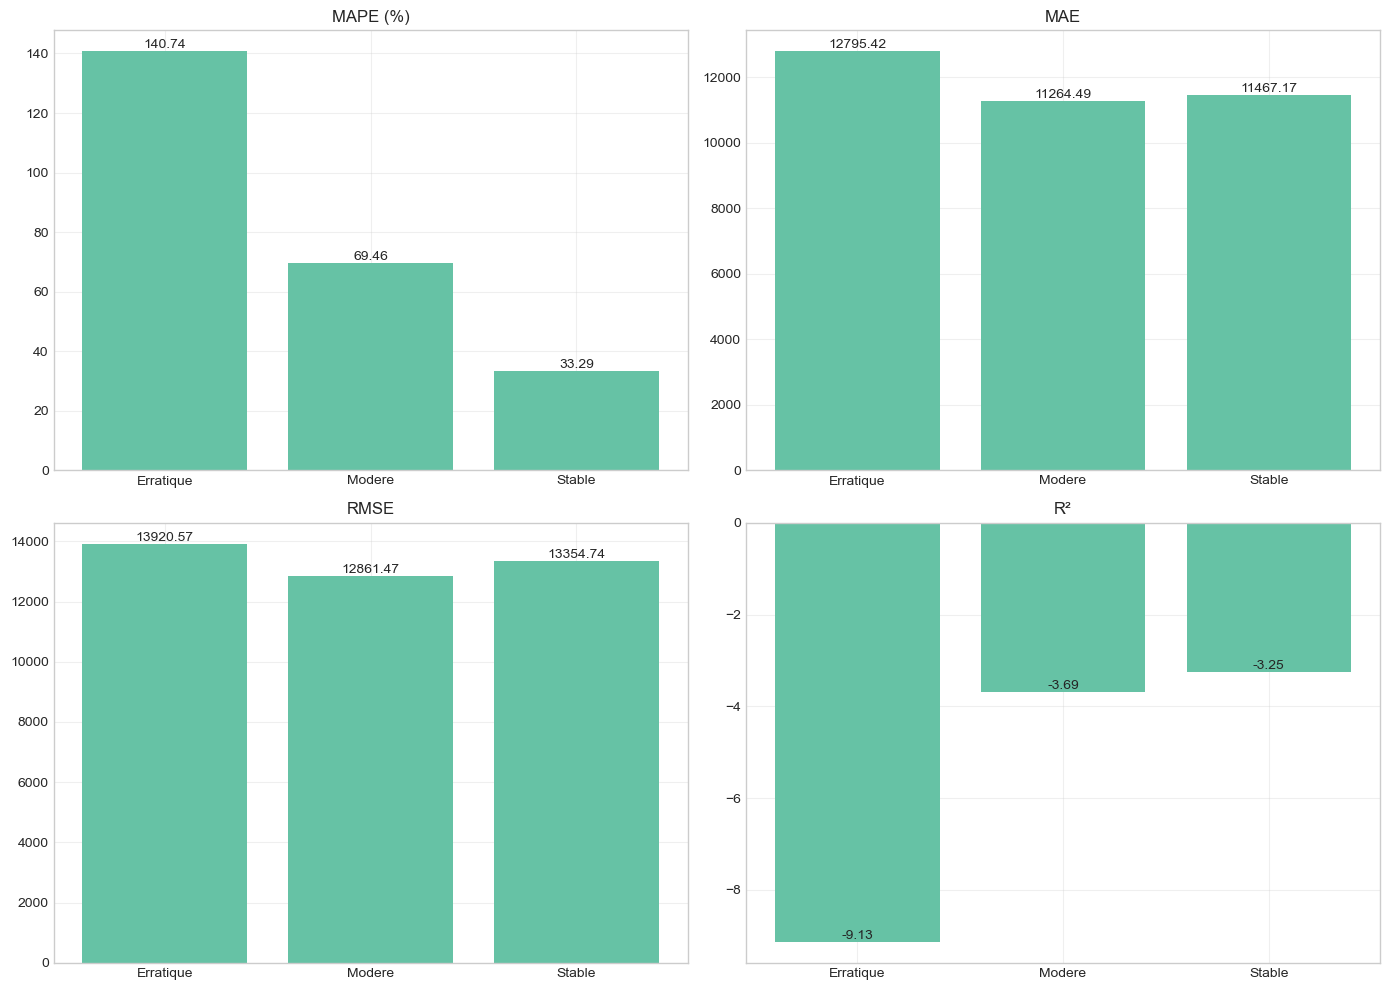

 performances_sarima_segments.png sauvegardé


In [102]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2,2, figsize=(14,10))

metrics = [
    ("MAPE","MAPE (%)"),
    ("MAE","MAE"),
    ("RMSE","RMSE"),
    ("R2","R²")
]

for ax,(metric,title) in zip(axes.ravel(),metrics):

    valeurs = resume_sarima[metric]

    ax.bar(
        resume_sarima["Segment"],
        valeurs
    )

    ax.set_title(title)

    ax.grid(alpha=0.30)

    for i,v in enumerate(valeurs):

        ax.text(
            i,
            v,
            f"{v:.2f}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()

plt.savefig(
    "performances_sarima_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(" performances_sarima_segments.png sauvegardé")